In [315]:
import pandas as pd
import yfinance as yf

In [316]:
df = pd.read_csv('data.csv')


df.columns


Index(['Issuer Ticker', 'Issuer Name', 'Sales - 1 Yr Growth', 'Profit Margin',
       'Return on Assets', 'Offer Size (M)', 'Shares Outstanding (M)',
       'Offer Price', 'Offer To 1st Close', 'Market Cap at Offer (M)',
       'Trade Date (US)', 'cusip', 'Cash Flow per Share',
       'Instit Owner (% Shares Out)', 'Instit Owner (Shares Held)',
       'Month/Date', 'Month of Quarter', 'Real GDP Per Capita',
       'OECD Leading Indicator', 'Interest Rate',
       'Seasonally Adjusted Unemployment Rate', 'CPI Growth Rate',
       'Filing Term Price Range', 'Priced Range', 'Industry Sector',
       'Industry Group', 'Industry Subgroup', 'Underpriced'],
      dtype='object')

## Collect Data from Ticker

In [317]:
def get_data(year):
    url = "https://ticker.com/IPO-Pricing/" + str(year) + "/"
    data = pd.read_html(url, header=1)[0]
    data["Year"] = year
    return data

In [318]:
!pip install xlrd


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [319]:
df_model = df
df_model.columns

Index(['Issuer Ticker', 'Issuer Name', 'Sales - 1 Yr Growth', 'Profit Margin',
       'Return on Assets', 'Offer Size (M)', 'Shares Outstanding (M)',
       'Offer Price', 'Offer To 1st Close', 'Market Cap at Offer (M)',
       'Trade Date (US)', 'cusip', 'Cash Flow per Share',
       'Instit Owner (% Shares Out)', 'Instit Owner (Shares Held)',
       'Month/Date', 'Month of Quarter', 'Real GDP Per Capita',
       'OECD Leading Indicator', 'Interest Rate',
       'Seasonally Adjusted Unemployment Rate', 'CPI Growth Rate',
       'Filing Term Price Range', 'Priced Range', 'Industry Sector',
       'Industry Group', 'Industry Subgroup', 'Underpriced'],
      dtype='object')

In [320]:
# 1. Create binary target in the DataFrame
df_model['1_day_up'] = (df['Offer To 1st Close'] > 0).astype(int)

# 2. Columns to drop from features (but keep 1_day_up)
cols_to_drop = ['Offer To 1st Close', 'Month/Date', 'Trade Date (US)', 
                'Priced Range', 'Filing Term Price Range', 'Underpriced']

# Drop unwanted columns
df_model = df_model.drop(columns=cols_to_drop)

# 3. Define features and target
X = df_model.drop(columns=['1_day_up'])  # all remaining columns
y = df_model['1_day_up']                 # binary target


In [321]:
df_model.to_csv('clean_data.csv', index=False)
df_model.columns

Index(['Issuer Ticker', 'Issuer Name', 'Sales - 1 Yr Growth', 'Profit Margin',
       'Return on Assets', 'Offer Size (M)', 'Shares Outstanding (M)',
       'Offer Price', 'Market Cap at Offer (M)', 'cusip',
       'Cash Flow per Share', 'Instit Owner (% Shares Out)',
       'Instit Owner (Shares Held)', 'Month of Quarter', 'Real GDP Per Capita',
       'OECD Leading Indicator', 'Interest Rate',
       'Seasonally Adjusted Unemployment Rate', 'CPI Growth Rate',
       'Industry Sector', 'Industry Group', 'Industry Subgroup', '1_day_up'],
      dtype='object')

In [322]:
print(f"1st Day - Positive: {(df_model['1_day_up']==1).sum()}, Negative: {(df_model['1_day_up']==0).sum()}")

1st Day - Positive: 1235, Negative: 465


df_model.columns

In [323]:
df_model.columns

Index(['Issuer Ticker', 'Issuer Name', 'Sales - 1 Yr Growth', 'Profit Margin',
       'Return on Assets', 'Offer Size (M)', 'Shares Outstanding (M)',
       'Offer Price', 'Market Cap at Offer (M)', 'cusip',
       'Cash Flow per Share', 'Instit Owner (% Shares Out)',
       'Instit Owner (Shares Held)', 'Month of Quarter', 'Real GDP Per Capita',
       'OECD Leading Indicator', 'Interest Rate',
       'Seasonally Adjusted Unemployment Rate', 'CPI Growth Rate',
       'Industry Sector', 'Industry Group', 'Industry Subgroup', '1_day_up'],
      dtype='object')

In [324]:
!pip install scikit-learn
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [325]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter


In [336]:

df_model = df_model.drop(columns=["Underpriced" 
                                   'Trade Date (US)', 'Month/Date', 
                                   'Month of Quarter', 'Filing Term Price Range', 
                                   'Priced Range'], errors='ignore')


In [340]:
df_model.columns
df_model.to_csv('clean_data.csv', index=False)

In [341]:
# Features: drop unwanted columns safely
X_numeric = df_model.drop(columns=['1_day_up', "Underpriced" 
                                   'Trade Date (US)', 'Month/Date', 
                                   'Month of Quarter', 'Filing Term Price Range', 
                                   'Priced Range'], errors='ignore')


# Target
y = df_model['1_day_up']
# Drop string/ID columns from features
X_numeric = X_numeric.drop(columns=['Issuer Ticker', 'Issuer Name', 'cusip'], errors='ignore')

# Now X_numeric should be fully numeric
print(X_numeric.dtypes)



Sales - 1 Yr Growth                      float64
Profit Margin                            float64
Return on Assets                         float64
Offer Size (M)                           float64
Shares Outstanding (M)                   float64
Offer Price                              float64
Market Cap at Offer (M)                  float64
Cash Flow per Share                      float64
Instit Owner (% Shares Out)              float64
Instit Owner (Shares Held)               float64
Real GDP Per Capita                        int64
OECD Leading Indicator                   float64
Interest Rate                            float64
Seasonally Adjusted Unemployment Rate    float64
CPI Growth Rate                          float64
Industry Sector                            int64
Industry Group                             int64
Industry Subgroup                          int64
dtype: object


In [342]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# -----------------------------
# 1. Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.3, stratify=y, random_state=42
)

print("Original training set class distribution:", Counter(y_train))

# -----------------------------
# 2. Apply SMOTE to training set only
# -----------------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Resampled training set class distribution:", Counter(y_train_res))


Original training set class distribution: Counter({1: 864, 0: 326})
Resampled training set class distribution: Counter({1: 864, 0: 864})


/Users/danielgarciabruna/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [329]:
print(f"1st Day - Positive: {(df_model['1_day_up']==1).sum()}, Negative: {(df_model['1_day_up']==0).sum()}")

1st Day - Positive: 1235, Negative: 465


In [330]:
# Before SMOTE
print("Original class distribution:")
print(y_train.value_counts())

# After SMOTE
print("\nResampled class distribution:")
print(pd.Series(y_train_res).value_counts())


Original class distribution:
1_day_up
1    864
0    326
Name: count, dtype: int64

Resampled class distribution:
1_day_up
1    864
0    864
Name: count, dtype: int64


In [331]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.3, stratify=y, random_state=42
)

print("Original training class distribution:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Resampled training class distribution:", Counter(y_train_res))

Original training class distribution: Counter({1: 864, 0: 326})
Resampled training class distribution: Counter({1: 864, 0: 864})


/Users/danielgarciabruna/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Random Forest Accuracy: 0.6843137254901961
Confusion Matrix:
 [[ 49  90]
 [ 71 300]]
Classification Report:
               precision    recall  f1-score   support

           0       0.41      0.35      0.38       139
           1       0.77      0.81      0.79       371

    accuracy                           0.68       510
   macro avg       0.59      0.58      0.58       510
weighted avg       0.67      0.68      0.68       510

ROC AUC: 0.6566347999767302


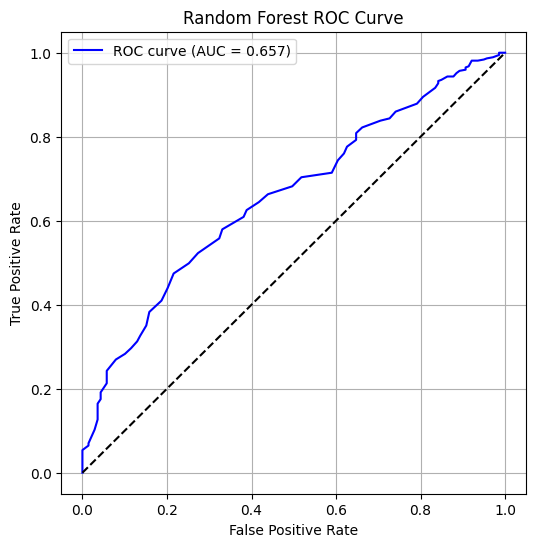

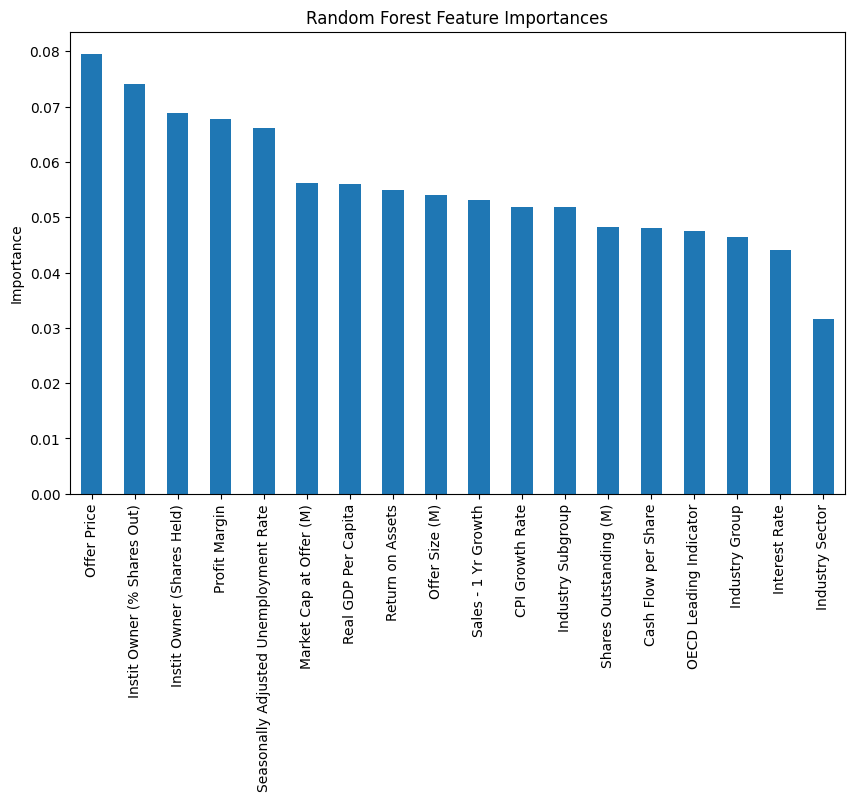

Top 10 features:
 Offer Price                              0.079573
Instit Owner (% Shares Out)              0.074098
Instit Owner (Shares Held)               0.068787
Profit Margin                            0.067690
Seasonally Adjusted Unemployment Rate    0.066105
Market Cap at Offer (M)                  0.056170
Real GDP Per Capita                      0.056005
Return on Assets                         0.054871
Offer Size (M)                           0.054079
Sales - 1 Yr Growth                      0.053160
dtype: float64
Decision Tree Accuracy: 0.5294117647058824
Decision Tree Confusion Matrix:
 [[ 91  48]
 [192 179]]
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.32      0.65      0.43       139
           1       0.79      0.48      0.60       371

    accuracy                           0.53       510
   macro avg       0.56      0.57      0.51       510
weighted avg       0.66      0.53      0.55       510



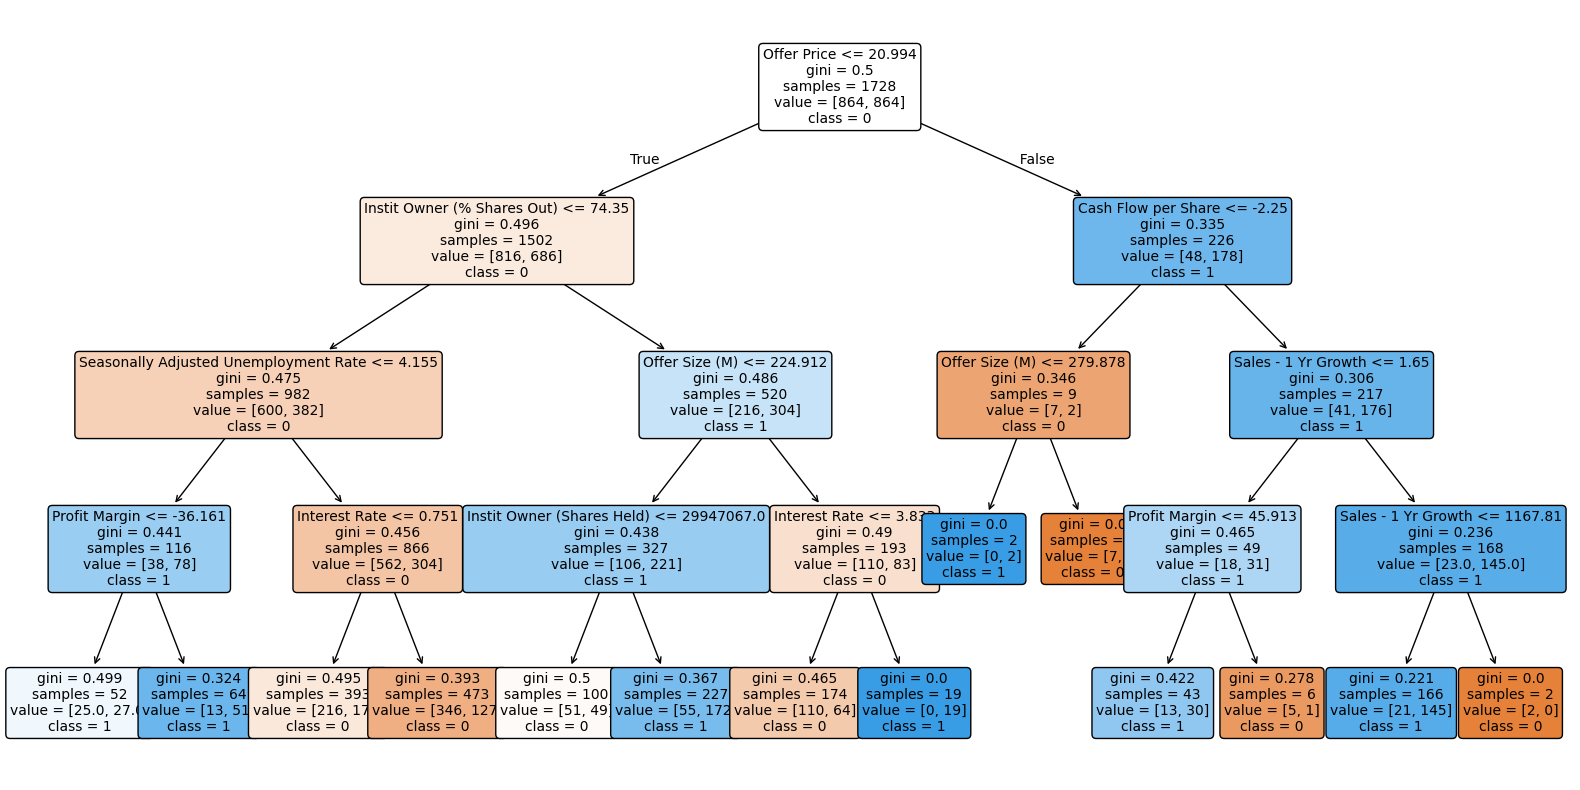

In [332]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd

# Train RF
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

# Predict on test set
y_pred = rf.predict(X_test)
y_probs = rf.predict_proba(X_test)[:, 1]

# Metrics
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# ROC AUC
auc = roc_auc_score(y_test, y_probs)
print("ROC AUC:", auc)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})', color='blue')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X_train_res.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance")
plt.show()
print("Top 10 features:\n", feat_imp.head(10))

# -----------------------------
# 3. Small Decision Tree
# -----------------------------
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train_res, y_train_res)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))

# Plot the tree
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X_train_res.columns, class_names=['0','1'],
          filled=True, rounded=True, fontsize=10)
plt.show()

In [348]:
df2 = pd.read_excel('IPOSCOOP-Dataset.xls')

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'IPO SCOOP Rating Scorecard',
       'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11'],
      dtype='object')